In [1]:
# Environment check 
import sys 
print(sys.executable)

/Users/iriskwon/Documents/Spr26/MLMA Final Project/MLMAMidtermProject/MLMA_Env/bin/python


In [2]:
# LSTM classifier for nurse stress prediction from sliding windows.
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM

from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## 1) Configuration and Helper Functions

This section defines windowing rules and preprocessing helpers for sequence modeling.

In [3]:
DATA_DIR = Path('data/Eric')
WINDOW_SECONDS = 30.0
FIXED_WINDOW_STEPS = 128  # Set an integer (e.g., 256) to force a fixed sequence length.
MAX_WINDOW_STEPS = 300      # Safety cap to avoid very large tensors.
STRIDE_FRACTION = 0.50
TEST_RATIO = 0.20 # Using 20-80 splits 
# NUM_EPOCHS = 30
NUM_EPOCHS = 10
BATCH_SIZE = 64

FEATURE_COLS = ['acc_mag', 'EDA', 'HR', 'TEMP']
TARGET_COL = 'label'

def infer_window_steps(time_values: np.ndarray, window_seconds: float) -> int:
    """
    Convert seconds to sample count using median time difference.
    """
    if len(time_values) < 2:
        return 1
    # compute consecutive time gaps 
    diffs = np.diff(time_values)
    # keep only positive gaps, ignore zero/invalid jumps in between 
    positive_diffs = diffs[diffs > 0]
    if len(positive_diffs) == 0:
        return 1
    dt = float(np.median(positive_diffs))
    return max(1, int(round(window_seconds / dt)))

def build_sequences(
    X: np.ndarray,
    y: np.ndarray,
    window_steps: int,
    stride_steps: int,
    end_point_label: bool = True,
 ) -> tuple[np.ndarray, np.ndarray]:
    if len(X) < window_steps:
        return np.empty((0, window_steps, X.shape[1]), dtype=np.float32), np.empty((0,), dtype=np.int8)

    X_seq = []
    y_seq = []
    for start in range(0, len(X) - window_steps + 1, stride_steps):
        end = start + window_steps
        X_seq.append(X[start:end])
        if end_point_label:
            y_seq.append(int(y[end - 1]))
        else:
            y_seq.append(int(np.round(y[start:end].mean())))

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.int8)

def scale_3d(train_3d: np.ndarray, test_3d: np.ndarray) -> tuple[np.ndarray, np.ndarray, StandardScaler]:
    """Standardizes features by fitting scaler on train data only, then applying to train/test. """
    scaler = StandardScaler()
    n_features = train_3d.shape[-1]
    train_2d = train_3d.reshape(-1, n_features)
    test_2d = test_3d.reshape(-1, n_features)
    train_scaled = scaler.fit_transform(train_2d).reshape(train_3d.shape).astype(np.float32)
    test_scaled = scaler.transform(test_2d).reshape(test_3d.shape).astype(np.float32)
    return train_scaled, test_scaled, scaler

## 2) Load Data and Build LSTM Sequences

Creates rolling windows per nurse and concatenates all windows for model training.

In [4]:
csv_files = sorted(DATA_DIR.glob('processed_nurse_*.csv'))
if not csv_files:
    raise FileNotFoundError(f'No processed_nurse_*.csv files found in {DATA_DIR}')

# Build per-nurse sequences first, then split by nurse group to prevent subject leakage.
X_all_list, y_all_list, group_list = [], [], []
nurse_stats = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    required = set(FEATURE_COLS + [TARGET_COL, 'time'])
    missing = required - set(df.columns)
    if missing:
        print(f'Skipping {csv_path.name}: missing columns {sorted(missing)}')
        continue

    df = df.sort_values('time').reset_index(drop=True)
    X = df[FEATURE_COLS].to_numpy(dtype=np.float32)
    # Binarize labels so any class > 0 maps to 1.
    df['label_bin'] = (df[TARGET_COL] > 0).astype(np.int8)
    y = df['label_bin'].to_numpy(dtype=np.int8)

    window_steps = FIXED_WINDOW_STEPS
    # window_steps = FIXED_WINDOW_STEPS if FIXED_WINDOW_STEPS is not None else infer_window_steps(df['time'].to_numpy(dtype=np.float32), WINDOW_SECONDS)
    window_steps = int(max(1, min(window_steps, MAX_WINDOW_STEPS)))
    stride_steps = int(max(1, round(window_steps * STRIDE_FRACTION)))

    X_seq, y_seq = build_sequences(
        X, y, window_steps=window_steps, stride_steps=stride_steps, end_point_label=True
    )
    if len(X_seq) < 2:
        print(f'Skipping {csv_path.name}: too few sequences ({len(X_seq)})')
        continue

    nurse_id = csv_path.stem.replace('processed_nurse_', '')
    X_all_list.append(X_seq)
    y_all_list.append(y_seq)
    group_list.append(np.full(len(X_seq), nurse_id, dtype=object))

    nurse_stats.append({
        'nurse_id': nurse_id,
        'window_steps': window_steps,
        'stride_steps': stride_steps,
        'num_sequences': int(len(X_seq)),
    })

if not X_all_list:
    raise RuntimeError('No valid nurse sequences were created. Check your data and settings.')

# Keep one common sequence length so tensors stack cleanly.
common_steps = min(arr.shape[1] for arr in X_all_list)
X_all = np.concatenate([arr[:, :common_steps, :] for arr in X_all_list], axis=0)
y_all = np.concatenate(y_all_list, axis=0)
groups = np.concatenate(group_list, axis=0)

unique_nurses = np.unique(groups)
if len(unique_nurses) < 2:
    raise RuntimeError('Need at least 2 nurses for group-based train/test split.')

n_splits = len(unique_nurses)
gkf = GroupKFold(n_splits=n_splits)
fold_splits = list(gkf.split(X_all, y_all, groups=groups))

print('Nurses used:', len(nurse_stats))
print('Number of nurse-group folds:', len(fold_splits))
print('X_all shape:', X_all.shape, 'y_all shape:', y_all.shape)
pd.DataFrame(nurse_stats).sort_values('nurse_id').reset_index(drop=True)

Nurses used: 15
Number of nurse-group folds: 15
X_all shape: (179809, 128, 4) y_all shape: (179809,)


,nurse_id,window_steps,stride_steps,num_sequences
0,15,128,64,4829
1,5C,128,64,13529
2,6B,128,64,12898
3,6D,128,64,9239
4,7A,128,64,21519
5,7E,128,64,3959
6,83,128,64,21449
7,8B,128,64,6620
8,94,128,64,9156
9,BG,128,64,9509


In [5]:
nurse_stats_df = pd.DataFrame(nurse_stats)
display(nurse_stats_df)

,nurse_id,window_steps,stride_steps,num_sequences
0,15,128,64,4829
1,5C,128,64,13529
2,6B,128,64,12898
3,6D,128,64,9239
4,7A,128,64,21519
5,7E,128,64,3959
6,83,128,64,21449
7,8B,128,64,6620
8,94,128,64,9156
9,BG,128,64,9509


In [6]:
assert nurse_stats_df['stride_steps'].nunique() == 1
assert nurse_stats_df['window_steps'].nunique() == 1
print('Window and stride are consistent across nurses.')

Window and stride are consistent across nurses.


## 3) Define and Train LSTM

A compact LSTM architecture with early stopping to reduce overfitting.

In [7]:
from tqdm.auto import tqdm

def make_lstm_model(n_timesteps: int, n_features: int) -> Sequential:
    model = Sequential([
        Input(shape=(n_timesteps, n_features)),
        LSTM(64, return_sequences=True),
        Dropout(0.25),
        LSTM(32),
        Dropout(0.20),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid'),
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model

fold_results = []
fold_histories = []
fold_test_payload = []
fold_models = []

for fold_no, (train_idx, test_idx) in tqdm(
    enumerate(fold_splits, start=1),
    total=len(fold_splits),
    desc='Training folds',
    unit='fold',
):
    X_train_raw, X_test_raw = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y_all[train_idx], y_all[test_idx]
    X_train, X_test, scaler = scale_3d(X_train_raw, X_test_raw)

    n_timesteps = X_train.shape[1]
    n_features = X_train.shape[2]
    model = make_lstm_model(n_timesteps=n_timesteps, n_features=n_features)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5),
    ]

    history = model.fit(
        X_train,
        y_train,
        epochs=NUM_EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1,
    )

    eval_values = model.evaluate(X_test, y_test, verbose=0)
    eval_metrics = dict(zip(model.metrics_names, eval_values))
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(np.int8)

    fold_info = {
        'fold': fold_no,
        'test_nurses': ','.join(np.unique(groups[test_idx]).tolist()),
        'num_train_windows': int(len(X_train)),
        'num_test_windows': int(len(X_test)),
        'test_loss': float(eval_metrics.get('loss', np.nan)),
        'test_accuracy': float(accuracy_score(y_test, y_pred)),
        'test_f1': float(f1_score(y_test, y_pred)),
        'test_auc': float(eval_metrics.get('auc', np.nan)),
        'test_precision': float(eval_metrics.get('precision', np.nan)),
        'test_recall': float(eval_metrics.get('recall', np.nan)),
    }
    fold_results.append(fold_info)
    fold_histories.append(history.history)
    fold_test_payload.append((y_test, y_pred))
    fold_models.append(model)

fold_results_df = pd.DataFrame(fold_results).sort_values('fold').reset_index(drop=True)
display(fold_results_df)

summary = fold_results_df[['test_accuracy', 'test_f1', 'test_auc', 'test_precision', 'test_recall']].agg(['mean', 'std'])
print('Cross-fold summary:')
display(summary)

best_fold_idx = int(fold_results_df['test_f1'].idxmax())
best_fold_row = fold_results_df.iloc[best_fold_idx]
best_history = fold_histories[best_fold_idx]
best_y_test, best_y_pred = fold_test_payload[best_fold_idx]
best_model = fold_models[best_fold_idx]
print('Best fold by F1:', int(best_fold_row['fold']), '| Test nurse(s):', best_fold_row['test_nurses'])

Training folds:   0%|          | 0/15 [00:00<?, ?fold/s]

Epoch 1/10
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 114s 57ms/step - accuracy: 0.7789 - auc: 0.6985 - loss: 0.4846 - precision: 0.7870 - recall: 0.9810 - val_accuracy: 0.7919 - val_auc: 0.6501 - val_loss: 0.3707 - val_precision: 0.9575 - val_recall: 0.8177 - learning_rate: 0.0010
Epoch 2/10
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 112s 57ms/step - accuracy: 0.7880 - auc: 0.7556 - loss: 0.4539 - precision: 0.8087 - recall: 0.9526 - val_accuracy: 0.8838 - val_auc: 0.5753 - val_loss: 0.3239 - val_precision: 0.9490 - val_recall: 0.9277 - learning_rate: 0.0010
Epoch 3/10
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 111s 56ms/step - accuracy: 0.8109 - auc: 0.7907 - loss: 0.4250 - precision: 0.8269 - recall: 0.9572 - val_accuracy: 0.9349 - val_auc: 0.6769 - val_loss: 0.3210 - val_precision: 0.9545 - val_recall: 0.9783 - learning_rate: 0.0010
Epoch 4/10
1958/1958 ━━━━━━━━━━━━━━━━━━━━ 111s 57ms/step - accuracy: 0.8353 - auc: 0.8359 - loss: 0.3848 - precision: 0.8474 - recall: 0.9611 - val_accuracy: 0.9241 - val_auc: 0.4209 - va

,fold,test_nurses,num_train_windows,num_test_windows,test_loss,test_accuracy,test_f1,test_auc,test_precision,test_recall
0,1,E4,156563,23246,0.871634,0.811021,0.895651,NaN,NaN,NaN
1,2,7A,158290,21519,0.285693,0.966541,0.982986,NaN,NaN,NaN
2,3,83,158360,21449,0.375199,0.881113,0.936800,NaN,NaN,NaN
3,4,DF,165620,14189,0.399606,0.822750,0.901546,NaN,NaN,NaN
4,5,5C,166280,13529,0.677352,0.642915,0.782652,NaN,NaN,NaN
5,6,6B,166911,12898,0.408739,0.827648,0.903695,NaN,NaN,NaN
6,7,CE,167090,12719,0.403970,1.000000,1.000000,NaN,NaN,NaN
7,8,BG,170300,9509,0.327598,0.965296,0.982342,NaN,NaN,NaN
8,9,6D,170570,9239,1.615513,0.149259,0.259748,NaN,NaN,NaN
9,10,94,170653,9156,1.505950,0.375164,0.545628,NaN,NaN,NaN


Cross-fold summary:


,test_accuracy,test_f1,test_auc,test_precision,test_recall
mean,0.761704,0.838116,NaN,NaN,NaN
std,0.247778,0.203952,NaN,NaN,NaN


Best fold by F1: 7 | Test nurse(s): CE


## 4) Evaluate and Visualize

Computes test metrics and plots training/validation curves.

Best fold metrics:


,fold,test_nurses,num_train_windows,num_test_windows,test_loss,test_accuracy,test_f1,test_auc,test_precision,test_recall
6,7,CE,167090,12719,0.40397,1.0,1.0,NaN,NaN,NaN


Best-fold classification report:

              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000     12719

    accuracy                         1.0000     12719
   macro avg     1.0000    1.0000    1.0000     12719
weighted avg     1.0000    1.0000    1.0000     12719

Best-fold confusion matrix:
 [[12719]]


/Users/iriskwon/Documents/Spr26/MLMA Final Project/MLMAMidtermProject/MLMA_Env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


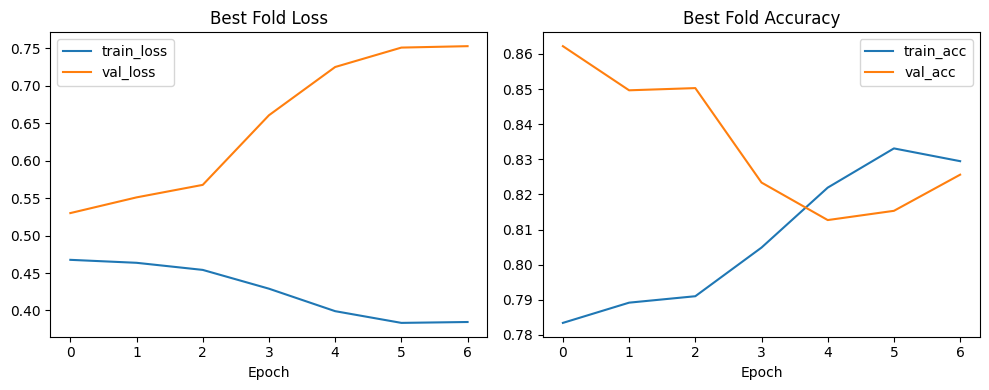

In [9]:
print('Best fold metrics:')
display(best_fold_row.to_frame().T)

print('Best-fold classification report:\n')
print(classification_report(best_y_test, best_y_pred, digits=4))
print('Best-fold confusion matrix:\n', confusion_matrix(best_y_test, best_y_pred))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history['loss'], label='train_loss')
plt.plot(best_history['val_loss'], label='val_loss')
plt.title('Best Fold Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_history['accuracy'], label='train_acc')
plt.plot(best_history['val_accuracy'], label='val_acc')
plt.title('Best Fold Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()